## 02 — Doublet Detection with Scrublet (Python)

**Purpose:** Score each cell for doublet probability using Scrublet. Results are TSV files consumed by notebooks 01 (FFPE) and 01 (nuc-seq) for doublet removal.

**Inputs:**
- Count matrices (MTX format) written by notebooks 01 (FFPE) and 01 (nuc-seq) before doublet filtering

**Outputs:**
- `scrublet_scores_*.tsv` files with per-cell doublet scores and predicted labels

**Note:** This is the only Python notebook. Run in a Python environment with `scrublet` and `scanpy` installed.

# Generate Scrublet scores

Simulates doublets and removes cells predicted to be of two cell types

Followed steps at: https://github.com/swolock/scrublet/blob/master/examples/scrublet_basics.ipynb

## Run scrublet on FFPE data

In [1]:
%matplotlib inline
import scrublet as scr
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import matplotlib.font_manager
plt.rcParams['font.family'] = 'sans-serif'
#plt.rcParams['font.sans-serif'] = 'Arial'
plt.rc('font', size=14)
plt.rcParams['pdf.fonttype'] = 42

In [2]:
input_dir = '../_data/ffpe/'
counts_matrix = scipy.io.mmread(input_dir + 'ffpe_exp_28947cells.mtx').T

print('Counts matrix shape: {} rows, {} columns'.format(counts_matrix.shape[0], counts_matrix.shape[1]))
counts_matrix

Counts matrix shape: 28947 rows, 16870 columns


<28947x16870 sparse matrix of type '<class 'numpy.int64'>'
	with 38785942 stored elements in COOrdinate format>

Run the default pipeline, which includes:
- Doublet simulation
- Normalization, gene filtering, rescaling, PCA
- Doublet score calculation
- Doublet score threshold detection and doublet calling

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.45
Detected doublet rate = 1.0%
Estimated detectable doublet fraction = 21.8%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.4%
Elapsed time: 38.1 seconds


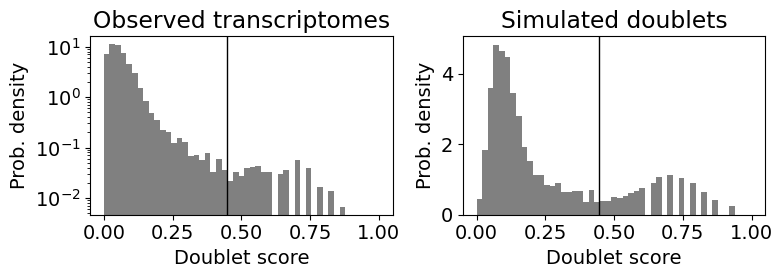

In [3]:
scrub = scr.Scrublet(counts_matrix, expected_doublet_rate=0.1)
doublet_scores, predicted_doublets = scrub.scrub_doublets()
scrub.plot_histogram();

Detected doublet rate = 1.1%
Estimated detectable doublet fraction = 23.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 4.8%


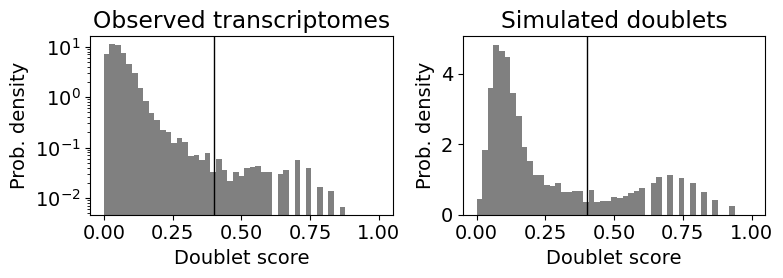

In [4]:
scrub.call_doublets(threshold=0.4)
scrub.plot_histogram();

Running UMAP...
Done.


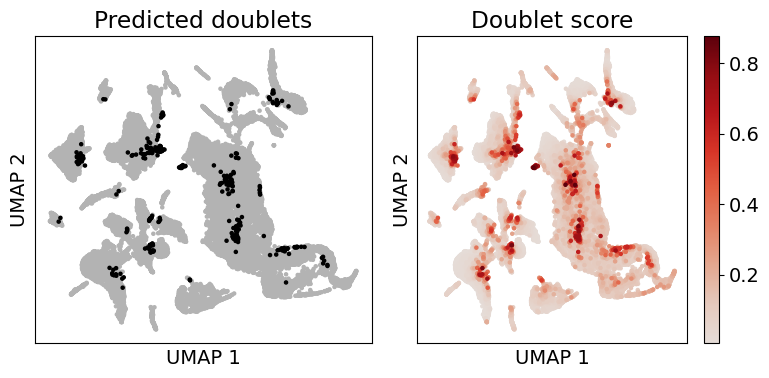

In [14]:
print('Running UMAP...')
import warnings
warnings.filterwarnings('ignore')
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True);

print('Done.')

In [15]:
df = pd.DataFrame(doublet_scores)
df.to_csv('../_data/ffpe/scrublet/scrublet_scores_28947cells.tsv',index=False, header= False)

## Run scrublet on nuc-seq data

In [16]:
input_dir = '../_data/snRNAseq/'
counts_matrix = scipy.io.mmread(input_dir + 'nucseq_exp_54750cells.mtx').T

print('Counts matrix shape: {} rows, {} columns'.format(counts_matrix.shape[0], counts_matrix.shape[1]))
counts_matrix

Counts matrix shape: 54750 rows, 31161 columns


<54750x31161 sparse matrix of type '<class 'numpy.int64'>'
	with 56044886 stored elements in COOrdinate format>

Run the default pipeline, which includes:
- Doublet simulation
- Normalization, gene filtering, rescaling, PCA
- Doublet score calculation
- Doublet score threshold detection and doublet calling

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.19
Detected doublet rate = 11.8%
Estimated detectable doublet fraction = 46.3%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 25.4%
Elapsed time: 129.7 seconds


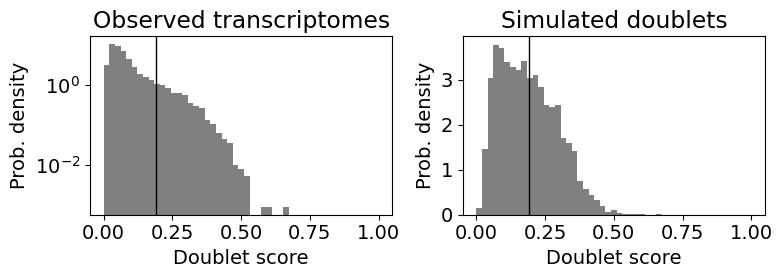

In [17]:
scrub = scr.Scrublet(counts_matrix, expected_doublet_rate=0.1)
doublet_scores, predicted_doublets = scrub.scrub_doublets()
scrub.plot_histogram();

Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 0.9%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 13.3%


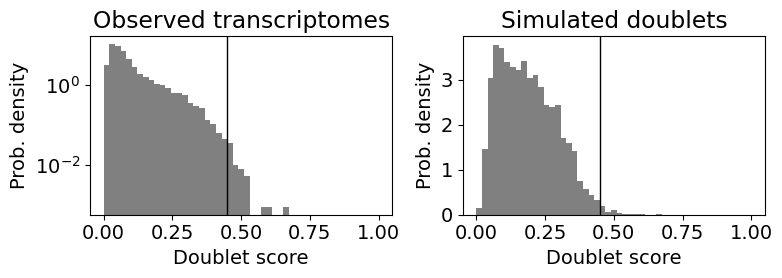

In [18]:
scrub.call_doublets(threshold=0.45)
scrub.plot_histogram();

Running UMAP...
Done.


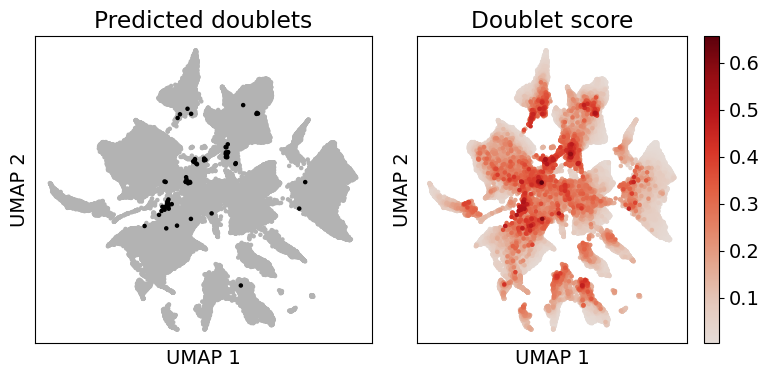

In [19]:
print('Running UMAP...')
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True);
    
print('Done.')

In [20]:
df = pd.DataFrame(doublet_scores)
df.to_csv('../_data/snRNAseq/scrublet/scrublet_scores_54750cells.tsv',index=False, header= False)

# Done!